# Exercise: MLP in TensorFlow (forward pass)

In this exercise, you are building a very simple **feed-forward neural network** (MLP, Multilayer Perceptron) with TensorFlow, without training it.

## What is this exercise for?
- Understand how to manually define neural network **weights** and **biases**.
- See how a **forward pass** is built: input -> hidden layers -> output.
- Get familiar with TensorFlow syntax for operations such as `tf.Variable`, `tf.matmul`, `tf.add`, and `tf.sigmoid`.

## What are we doing?
1. Import libraries (`numpy`, `matplotlib`, `tensorflow`).
2. Set a random seed to make results reproducible.
3. Define the network architecture (number of neurons per layer).
4. Initialize weights and biases randomly.
5. Write the `multilayer_perceptron(x)` function that computes the output.
6. Create a small input vector and print the predictions.

### Exercise 1

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

I0000 00:00:1785944185.490378   30107 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1785944185.561140   30107 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# Set the seed so random values are reproducible at every run
tf.random.set_seed(0)

# Network sizes: 1 input -> 5 neurons -> 2 neurons -> 1 output
n_input = 1
n_hidden_1 = 5
n_hidden_2 = 2
n_output = 1

# Weights dictionary: each matrix connects one layer to the next
# 'h1' shape [1, 5], 'h2' shape [5, 2], 'out' shape [2, 1]
weights = {
    'h1': tf.Variable(tf.random.normal([n_input, n_hidden_1])),
    'h2': tf.Variable(tf.random.normal([n_hidden_1, n_hidden_2])),
    'out': tf.Variable(tf.random.normal([n_hidden_2, n_output]))
}

# Bias dictionary: one vector for each destination layer
# 'b1' shape [5], 'b2' shape [2], 'out' shape [1]
biases = {
    'b1': tf.Variable(tf.random.normal([n_hidden_1])),
    'b2': tf.Variable(tf.random.normal([n_hidden_2])),
    'out': tf.Variable(tf.random.normal([n_output]))
}

In [3]:
# Define the network forward pass (no training in this exercise)
def multilayer_perceptron(x):
    # tf.matmul(A, B): matrix-matrix multiplication
    # tf.add(..., bias): adds bias (automatic broadcasting)
    # tf.sigmoid(...): non-linear activation function
    layer_1 = tf.sigmoid(tf.add(tf.matmul(x, weights['h1']), biases['b1']))

    # Second hidden layer with the same logic
    layer_2 = tf.sigmoid(tf.add(tf.matmul(layer_1, weights['h2']), biases['b2']))

    # Linear output layer (no final sigmoid)
    out_layer = tf.matmul(layer_2, weights['out']) + biases['out']
    return out_layer


# Create 10 values between -2 and 2, then reshape to a column vector
x = np.linspace(-2, 2, 10, dtype=np.float32).reshape(-1, 1)

# Print the network predictions for each input
print(multilayer_perceptron(x))

tf.Tensor(
[[-2.476687 ]
 [-2.5830894]
 [-2.6968765]
 [-2.7944713]
 [-2.8631544]
 [-2.9048204]
 [-2.9268866]
 [-2.9360032]
 [-2.937006 ]
 [-2.9335563]], shape=(10, 1), dtype=float32)


### Exercise 2

In [4]:
# fix random seed
tf.random.set_seed(0)

n_input = 1
n_hidden_1 = 5
n_hidden_2 = 2
n_output = 1

weights = {
    'h1': tf.Variable(tf.random.normal([n_input, n_hidden_1])),
    'h2': tf.Variable(tf.random.normal([n_hidden_1, n_hidden_2])),
    'out': tf.Variable(tf.random.normal([n_hidden_2, n_output]))
}

biases = {
    'b1': tf.Variable(tf.random.normal([n_hidden_1])),
    'b2': tf.Variable(tf.random.normal([n_hidden_2])),
    'out': tf.Variable(tf.random.normal([n_output]))
}

# Create model
def multilayer_perceptron(x):
    layer_1 = tf.sigmoid(tf.add(tf.matmul(x, weights['h1']), biases['b1']))
    layer_2 = tf.sigmoid(tf.add(tf.matmul(layer_1, weights['h2']), biases['b2']))
    out_layer = tf.matmul(layer_2, weights['out']) + biases['out']
    return out_layer

# print predictions
x = np.linspace(-2, 2, 10, dtype=np.float32).reshape(-1, 1)
y1 = multilayer_perceptron(x)

# Sequential model
model = tf.keras.models.Sequential()
model.add(tf.keras.layers.Input(shape=(1,)))
model.add(tf.keras.layers.Dense(n_hidden_1, activation='sigmoid'))
model.add(tf.keras.layers.Dense(n_hidden_2, activation='sigmoid'))
model.add(tf.keras.layers.Dense(n_output, activation='linear'))
model.summary()

# assign parameters from previous model
model.set_weights([weights["h1"], biases["b1"],
                   weights["h2"], biases["b2"],
                   weights["out"], biases["out"]])
y2 = model.predict(x)

if not np.allclose(y1, y2):
    raise ValueError("results do not match")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 5)              │            10 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │            12 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             3 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25 (100.00 B)

 Trainable params: 25 (100.00 B)

 Non-trainable params: 0 (0.00 B)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step


### Exercise 3

In [5]:
# data generation

def model(x):
    return 3.0*x + 2.0

def generate_data():
    # A vector of random x values
    x = tf.linspace(-2, 2, 200)
    x = tf.cast(x, tf.float32)

    # Generate some noise
    noise = tf.random.normal(shape=x.shape)

    # Calculate y
    y = model(x) + noise
    return x, y

# linear fit

class LinearModel(tf.Module):
    def __init__(self):
        super().__init__()
        self.w = tf.Variable(tf.random.normal([1]), name='weight')
        self.b = tf.Variable(tf.random.normal([1]), name='bias')

    def __call__(self, x):
        return self.w * x + self.b
    
# define the loss function (mean squared error)
def mean_squared_error(y_pred, y_true):
    return tf.reduce_mean(tf.square(y_pred - y_true))

#training loop
def train(model, x, y, learning_rate=0.01):
    with tf.GradientTape() as tape:
        y_pred = model(x)
        loss = mean_squared_error(y_pred, y)
        
    gradients = tape.gradient(loss, [model.w, model.b])
    model.w.assign_sub(learning_rate * gradients[0])
    model.b.assign_sub(learning_rate * gradients[1])
    return loss

def report(model, loss):
    # Convert Tensor/ndarray values to Python scalars for f-string formatting.
    w = float(model.w.numpy().squeeze())
    b = float(model.b.numpy().squeeze())
    loss_value = float(loss.numpy() if hasattr(loss, 'numpy') else loss)
    return f"W = {w:1.2f}, b = {b:1.2f}, loss={loss_value:2.5f}"


def training_loop(model, x, y, epochs):

    # Collect the history of W-values and b-values to plot later
    weights = []
    biases = []
    losses = []

    for epoch in range(epochs):
        # Update the model with the single giant batch
        current_loss = train(model, x, y, learning_rate=0.1)

        # Track this before I update
        weights.append(model.w.numpy())
        biases.append(model.b.numpy())
        losses.append(current_loss)

        print(f"Epoch {epoch:2d}:")
        print("    ", report(model, current_loss))

    return weights, biases, losses

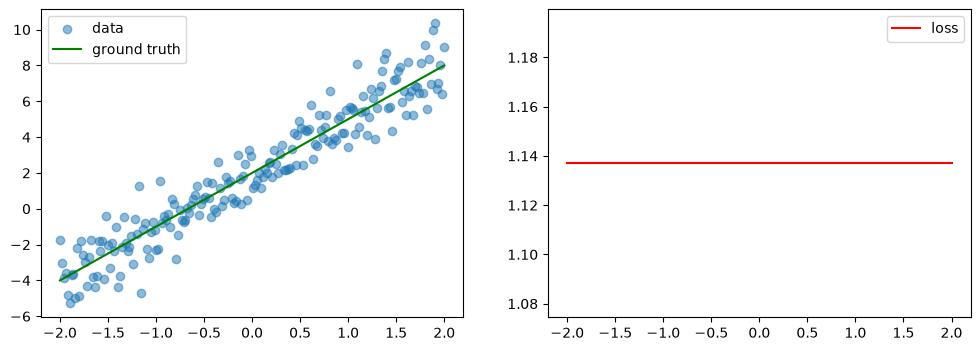

In [6]:
# Plot data, ground truth model, predictions and loss function for the untrained model.
x,y = generate_data()
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.scatter(x, y, label='data', alpha=0.5)
plt.plot(x, model(x), label='ground truth', color='green')
plt.legend()    
plt.subplot(1, 2, 2)
# Plot the loss function for the untrained model
loss = mean_squared_error(model(x), y)
plt.plot(x, loss * tf.ones_like(x), label='loss', color='red')
plt.legend()
plt.show()





In [10]:
# Print the evolution of weights at each iteration.
# Training

# saving loss and weights for plotting
losses_history = []
weights_history = []
biases_history = []

current_model = LinearModel()
current_model.w.assign([0.0])
current_model.b.assign([0.0])

current_loss = mean_squared_error(current_model(x), y)
print("Before training:")
print("    ", report(current_model, current_loss))

print("\nTraining:")
weights, biases, losses = training_loop(current_model, x, y, epochs=50)
weights_history.append(weights)
biases_history.append(biases)
losses_history.append(losses)
print("\nAfter training:")
current_loss = mean_squared_error(current_model(x), y)
print("    ", report(current_model, current_loss))

Before training:
     W = 0.00, b = 0.00, loss=17.54461

Training:
Epoch  0:
     W = 0.82, b = 0.40, loss=17.54461
Epoch  1:
     W = 1.42, b = 0.71, loss=10.31323
Epoch  2:
     W = 1.86, b = 0.97, loss=6.30216
Epoch  3:
     W = 2.18, b = 1.17, loss=4.06448
Epoch  4:
     W = 2.41, b = 1.33, loss=2.80820
Epoch  5:
     W = 2.58, b = 1.46, loss=2.09807
Epoch  6:
     W = 2.70, b = 1.57, loss=1.69370
Epoch  7:
     W = 2.80, b = 1.65, loss=1.46166
Epoch  8:
     W = 2.86, b = 1.72, loss=1.32743
Epoch  9:
     W = 2.91, b = 1.77, loss=1.24916
Epoch 10:
     W = 2.95, b = 1.81, loss=1.20313
Epoch 11:
     W = 2.97, b = 1.85, loss=1.17584
Epoch 12:
     W = 2.99, b = 1.88, loss=1.15954
Epoch 13:
     W = 3.01, b = 1.90, loss=1.14973
Epoch 14:
     W = 3.02, b = 1.92, loss=1.14378
Epoch 15:
     W = 3.02, b = 1.93, loss=1.14015
Epoch 16:
     W = 3.03, b = 1.94, loss=1.13792
Epoch 17:
     W = 3.03, b = 1.95, loss=1.13654
Epoch 18:
     W = 3.04, b = 1.96, loss=1.13569
Epoch 19:
     W = 

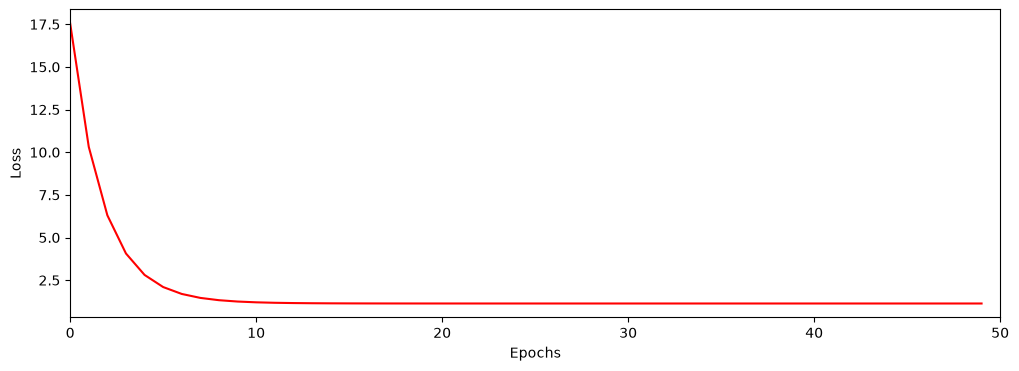

In [13]:
# plot losses over epochs
plt.figure(figsize=(12, 4))

plt.plot(losses, label='loss', color='red')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.xlim(0, 50)
plt.show()

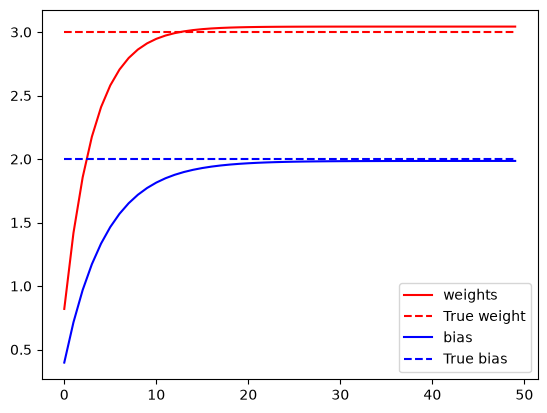

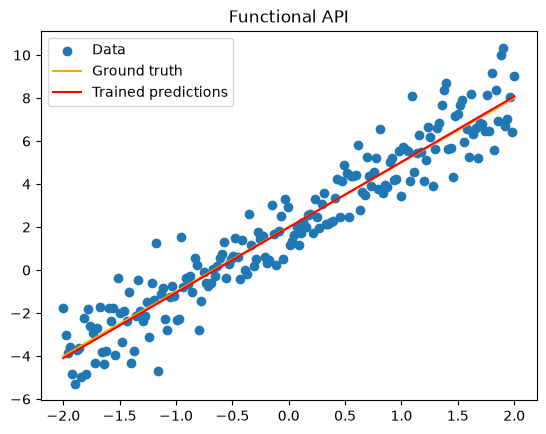

In [17]:
# Plot data, ground truth model, predictions and loss function after training.

# Build a matching epoch axis from training history length
epochs = range(len(weights))

# Convert history values from shape (1,) arrays to scalars for clean plotting
weights_plot = [float(np.asarray(w).squeeze()) for w in weights]
biases_plot = [float(np.asarray(b).squeeze()) for b in biases]

# Predictions from the trained linear model
y_trained = current_model(x)

# Plot parameter convergence
plt.figure()
plt.plot(epochs, weights_plot, 'r', label='weights')
plt.plot(epochs, [3.0] * len(weights_plot), 'r--', label='True weight')
plt.plot(epochs, biases_plot, 'b', label='bias')
plt.plot(epochs, [2.0] * len(biases_plot), 'b--', label='True bias')
plt.legend()

# Plot data and model predictions
plt.figure()
plt.scatter(x, y, label='Data')
plt.plot(x, model(x), 'orange', label='Ground truth')
plt.plot(x, y_trained, 'red', label='Trained predictions')
plt.title('Functional API')
plt.legend()
plt.show()